<a href="https://colab.research.google.com/github/Sairakesh08/Ensuring-Skin-Cancer/blob/main/DataLoad%26Visuvalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
dataset_dir = "/content/drive/MyDrive/dataset/"
if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)
    print("Folder 'dataset' created in Google Drive.")
else:
    print("Folder 'dataset' already exists. Skipping creation.")

files_to_download = {
    "ISIC_2019_Training_Input.zip": "https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_Input.zip",
    "ISIC_2019_Training_GroundTruth.csv": "https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Training_GroundTruth.csv",
    "ISIC_2019_Test_Input.zip": "https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_Input.zip",
    "ISIC_2019_Test_GroundTruth.csv": "https://isic-challenge-data.s3.amazonaws.com/2019/ISIC_2019_Test_GroundTruth.csv"
}

for filename, url in files_to_download.items():
    file_path = os.path.join(dataset_dir, filename)
    if os.path.exists(file_path):
        print(f"'{filename}' already downloaded. Skipping.")
    else:
        print(f"⬇ Downloading '{filename}'...")
        !wget -O "{file_path}" "{url}"

Folder 'dataset' already exists. Skipping creation.
'ISIC_2019_Training_Input.zip' already downloaded. Skipping.
'ISIC_2019_Training_GroundTruth.csv' already downloaded. Skipping.
'ISIC_2019_Test_Input.zip' already downloaded. Skipping.
'ISIC_2019_Test_GroundTruth.csv' already downloaded. Skipping.


In [ ]:
import zipfile
train_zip = os.path.join(dataset_dir, "ISIC_2019_Training_Input.zip")
test_zip = os.path.join(dataset_dir, "ISIC_2019_Test_Input.zip")

train_extract_dir = os.path.join(dataset_dir, "ISIC_2019_Training_Input")
test_extract_dir = os.path.join(dataset_dir, "ISIC_2019_Test_Input")

if not os.path.exists(train_extract_dir):
    os.makedirs(train_extract_dir, exist_ok=True)
    with zipfile.ZipFile(train_zip, 'r') as zip_ref:
        zip_ref.extractall(train_extract_dir)
    print("Extracted training images.")
else:
    print("Training images folder already exists. Skipping extraction.")

if not os.path.exists(test_extract_dir):
    os.makedirs(test_extract_dir, exist_ok=True)
    with zipfile.ZipFile(test_zip, 'r') as zip_ref:
        zip_ref.extractall(test_extract_dir)
    print("Extracted test images.")
else:
    print("Test images folder already exists. Skipping extraction.")

Training images folder already exists. Skipping extraction.
Test images folder already exists. Skipping extraction.


In [ ]:
import os

contents = os.listdir(dataset_dir)

folders = [item for item in contents if os.path.isdir(os.path.join(dataset_dir, item))]
files = [item for item in contents if os.path.isfile(os.path.join(dataset_dir, item))]

print("Folders in 'dataset':")
for folder in folders:
    print("  -", folder)

print("\n Files in 'dataset':")
for file in files:
    print("  -", file)


Folders in 'dataset':
  - ISIC_2019_Training_Input
  - ISIC_2019_Test_Input

 Files in 'dataset':
  - ISIC_2019_Training_GroundTruth.csv
  - ISIC_2019_Test_Input.zip
  - ISIC_2019_Training_Input.zip
  - ISIC_2019_Test_GroundTruth.csv


In [ ]:
from collections import Counter

def count_files_by_type_recursive(folder_path):
    extensions = []
    file_count = 0

    for root, _, files in os.walk(folder_path):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            extensions.append(ext)
            file_count += 1

    return file_count, Counter(extensions)

train_folder = os.path.join(dataset_dir, "ISIC_2019_Training_Input")
test_folder = os.path.join(dataset_dir, "ISIC_2019_Test_Input")

train_total, train_types = count_files_by_type_recursive(train_folder)
test_total, test_types = count_files_by_type_recursive(test_folder)

print(f"Training Folder: {train_total} files total")
for ext, count in train_types.items():
    print(f"  - {ext}: {count}")

print(f"\nTest Folder: {test_total} files total")
for ext, count in test_types.items():
    print(f"  - {ext}: {count}")

Training Folder: 25333 files total
  - .jpg: 25331
  - .txt: 2

Test Folder: 8240 files total
  - .jpg: 8238
  - .txt: 2


In [ ]:
import os
from collections import Counter

def count_files_by_type_recursive(folder_path):
    extensions = []
    file_count = 0

    for root, _, files in os.walk(folder_path):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            extensions.append(ext)
            file_count += 1

    return file_count, Counter(extensions)

train_folder = os.path.join(dataset_dir, "ISIC_2019_Training_Input")
test_folder = os.path.join(dataset_dir, "ISIC_2019_Test_Input")

train_total, train_types = count_files_by_type_recursive(train_folder)
test_total, test_types = count_files_by_type_recursive(test_folder)

print(f"Training Folder: {train_total} files total")
for ext, count in train_types.items():
    print(f"  - {ext}: {count}")

print(f"\nTest Folder: {test_total} files total")
for ext, count in test_types.items():
    print(f"  - {ext}: {count}")

# Expected counts for ISIC 2019
expected_train_count = 25331  # Number of images in training set
expected_test_count = 8238   # Number of images in test set

# Check and print results
print("\nValidation:")
print(f"Training set count: {'Valid' if train_types['.jpg'] == expected_train_count else 'Invalid'}")
print(f"Test set count: {'Valid' if test_types['.jpg'] == expected_test_count else 'Invalid'}")

Training Folder: 25333 files total
  - .jpg: 25331
  - .txt: 2

Test Folder: 8240 files total
  - .jpg: 8238
  - .txt: 2

Validation:
Training set count: Valid
Test set count: Valid


In [ ]:
import pandas as pd
train_labels = pd.read_csv(os.path.join(dataset_dir, "ISIC_2019_Training_GroundTruth.csv"))
test_labels = pd.read_csv(os.path.join(dataset_dir, "ISIC_2019_Test_GroundTruth.csv"))

print("Training labels sample:")
display(train_labels.head())

print("Test labels sample:")
display(test_labels.head())

Training labels sample:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Test labels sample:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK,score_weight,validation_weight
0,ISIC_0034321,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,ISIC_0034322,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,ISIC_0034323,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,ISIC_0034324,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,ISIC_0034325,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
full_class_names = {
    "MEL": "Melanoma",
    "NV": "Melanocytic nevus",
    "BCC": "Basal cell carcinoma",
    "AK": "Actinic keratosis",
    "BKL": "Benign keratosis",
    "DF": "Dermatofibroma",
    "VASC": "Vascular lesion",
    "SCC": "Squamous cell carcinoma",
    "UNK": "Unknown"
}

train_labels = train_labels.rename(columns=full_class_names)

class_columns_full = list(full_class_names.values())

train_labels["label_index"] = train_labels[class_columns_full].values.argmax(axis=1)

train_img_folder = os.path.join(dataset_dir, "ISIC_2019_Training_Input", "ISIC_2019_Training_Input")
train_labels["image_path"] = train_labels["image"].apply(lambda x: os.path.join(train_img_folder, x + ".jpg"))

label_map = {i: name for i, name in enumerate(class_columns_full)}
print("Updated label map:")
for i, name in label_map.items():
    print(f"{i}: {name}")

train_labels[["image", "image_path", "label_index"] + class_columns_full].head()


Updated label map:
0: Melanoma
1: Melanocytic nevus
2: Basal cell carcinoma
3: Actinic keratosis
4: Benign keratosis
5: Dermatofibroma
6: Vascular lesion
7: Squamous cell carcinoma
8: Unknown


,image,image_path,label_index,Melanoma,Melanocytic nevus,Basal cell carcinoma,Actinic keratosis,Benign keratosis,Dermatofibroma,Vascular lesion,Squamous cell carcinoma,Unknown
0,ISIC_0000000,/content/drive/MyDrive/dataset/ISIC_2019_Train...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,/content/drive/MyDrive/dataset/ISIC_2019_Train...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,/content/drive/MyDrive/dataset/ISIC_2019_Train...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,/content/drive/MyDrive/dataset/ISIC_2019_Train...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,/content/drive/MyDrive/dataset/ISIC_2019_Train...,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
test_labels = test_labels.rename(columns=full_class_names)

class_columns_full = list(full_class_names.values())

test_labels["label_index"] = test_labels[class_columns_full].values.argmax(axis=1)

test_img_folder = os.path.join(dataset_dir, "ISIC_2019_Test_Input", "ISIC_2019_Test_Input")
test_labels["image_path"] = test_labels["image"].apply(lambda x: os.path.join(test_img_folder, x + ".jpg"))

test_labels[["image", "image_path", "label_index"] + class_columns_full].head()

,image,image_path,label_index,Melanoma,Melanocytic nevus,Basal cell carcinoma,Actinic keratosis,Benign keratosis,Dermatofibroma,Vascular lesion,Squamous cell carcinoma,Unknown
0,ISIC_0034321,/content/drive/MyDrive/dataset/ISIC_2019_Test_...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0034322,/content/drive/MyDrive/dataset/ISIC_2019_Test_...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0034323,/content/drive/MyDrive/dataset/ISIC_2019_Test_...,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0034324,/content/drive/MyDrive/dataset/ISIC_2019_Test_...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0034325,/content/drive/MyDrive/dataset/ISIC_2019_Test_...,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


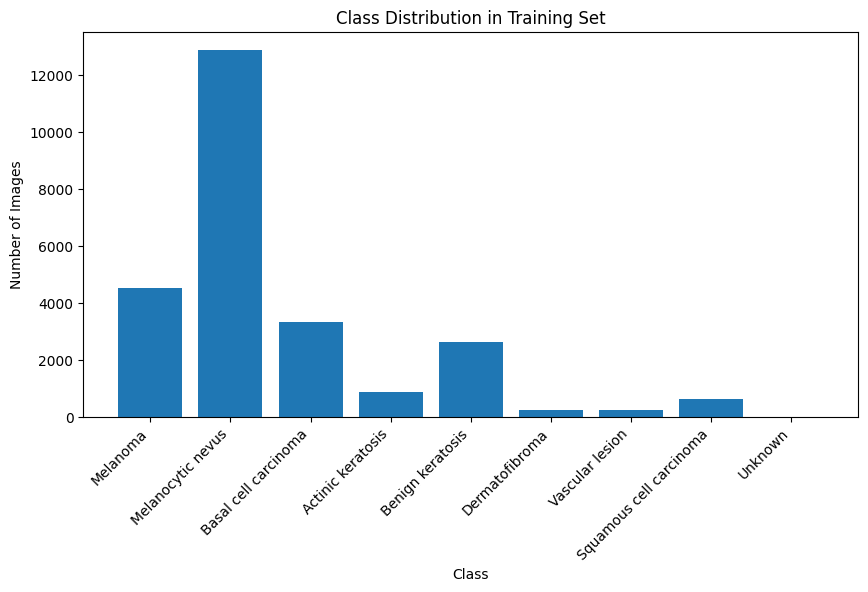

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'train_labels' is your DataFrame with label information
class_counts = train_labels[class_columns_full].sum()  # Sum of each class column

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.show()

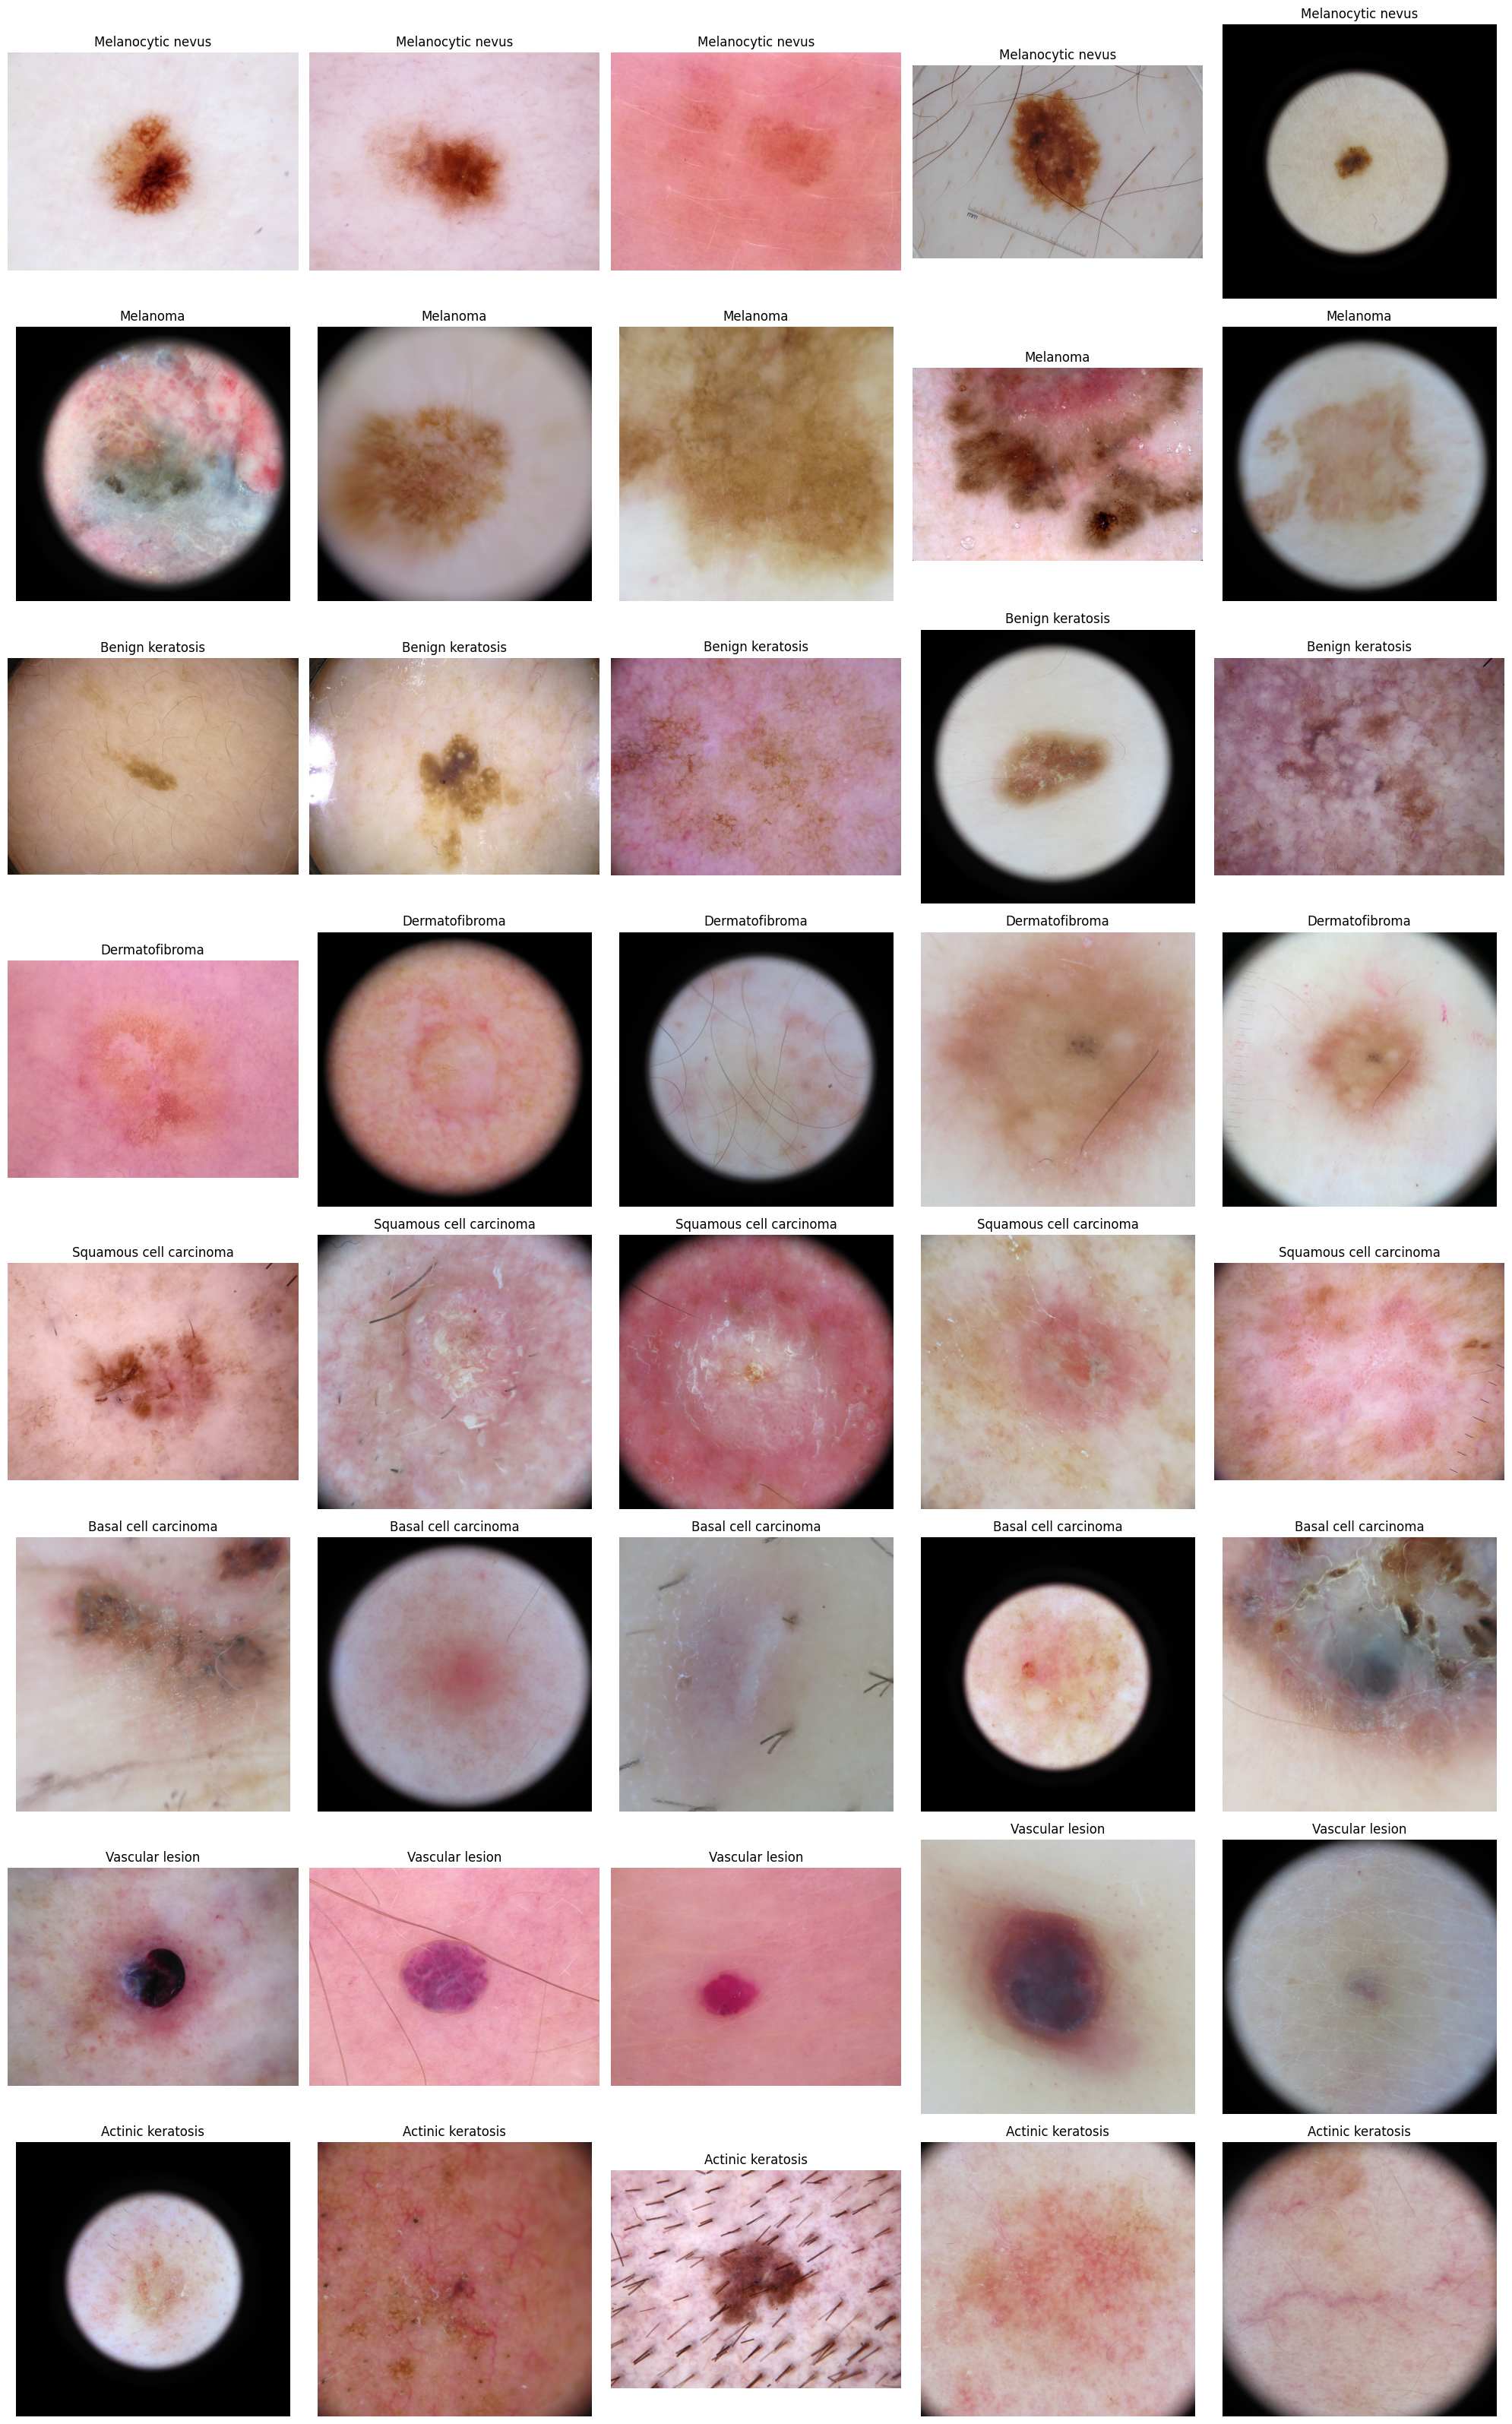

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

unique_labels = train_labels['label_index'].unique()

fig, axes = plt.subplots(len(unique_labels), 5, figsize=(20, 4 * len(unique_labels)))

for i, label in enumerate(unique_labels):
    image_paths = train_labels[train_labels['label_index'] == label]['image_path'].sample(5).values

    for j, path in enumerate(image_paths):
        img = plt.imread(path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        axes[i, j].set_title(label_map[label])

plt.tight_layout()
plt.show()